# RFM-анализ клиентской базы аптечной сети

### Цель проекта

В условиях сезонного снижения выручки аптечная сеть хочет выделить клиентские сегменты и использовать SMS-рассылки для стимулирования повторных покупок и роста выручки.
Основная задача — определить клиентов с высоким потенциалом удержания и определить приоритетные группы для маркетинговых коммуникаций.

### Цели исследования

- выделить клиентские сегменты по поведению покупателей
- определить, какие сегменты приносят основную выручку
- предложить практические рекомендации по удержанию и реактивации клиентов

### Бизнес-контекст

Проект помогает понять, какие клиенты приносят основную выручку, кого важно удерживать в первую очередь и какие сегменты можно возвращать недорогими коммуникациями.

### Структура данных

Для анализа использовалась таблица транзакций по бонусным картам. В работу включались только те покупки, где клиент мог быть идентифицирован по карте. Это важно, потому что офлайн-операции без привязки к карте не дают возможности корректно оценить поведение клиента.

**Таблица включает в себя следующие столбцы:**

- `datetime` - дата и время совершения транзакции
- `shop` - наименование аптеки
- `card` - номер карты
- `bonus_earned` - количество полученных бонусов
- `bonus_spent` - количество списанных бонусов
- `summ` - итоговая сумма чека
- `doc_id` - номер документа

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

### Подключение к данным

In [2]:
load_dotenv()

DATABASE_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:"
    f"{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:"
    f"{os.getenv('DB_PORT')}/"
    f"{os.getenv('DB_NAME')}"
)

engine = create_engine(DATABASE_URL)

Для дальнейшего удобства сразу напишем настройки для графиков и импортируем вспомогательные методы визуализации

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [4]:
from src.visualization.plot_rfm_share import plot_rfm_share
from src.visualization.plot_pareto import plot_pareto

In [5]:
def read_sql_from_file(filename):
    base = Path("sql/_base.sql").read_text(encoding="utf-8").rstrip()
    tail = Path(f"sql/{filename}.sql").read_text(encoding="utf-8").lstrip()
    query = f"{base}\n{tail}"
    return pd.read_sql(text(query), engine)

### RFM-сегментация клиентов

RFM-анализ позволяет разделить клиентов по трем измерениям: давности последней покупки, частоте покупок и сумме трат. 

Посмотрим, как распределяются клиенты по сегментам и какую долю выручки каждый сегмент формирует.

In [6]:
rfm_df = read_sql_from_file("rfm_segmentation")
rfm_df_sorted = rfm_df.sort_values(by="revenue_share_pct", ascending=False)
rfm_df_sorted

,segment,customers,total_customers,total_revenue_per_segment,avg_revenue_per_customer,customer_share_pct,revenue_share_pct
2,Чемпионы,964,5926.0,10371849.0,10759.18,16.27,54.03
0,Лояльные,2135,5926.0,6240110.0,2922.77,36.03,32.51
3,Под угрозой,849,5926.0,1027741.0,1210.53,14.33,5.35
4,Нельзя терять,802,5926.0,854217.0,1065.11,13.53,4.45
1,Потерянные,1176,5926.0,702923.0,597.72,19.84,3.66


Каждый сегмент описывает количество клиентов и вклад в выручку. 

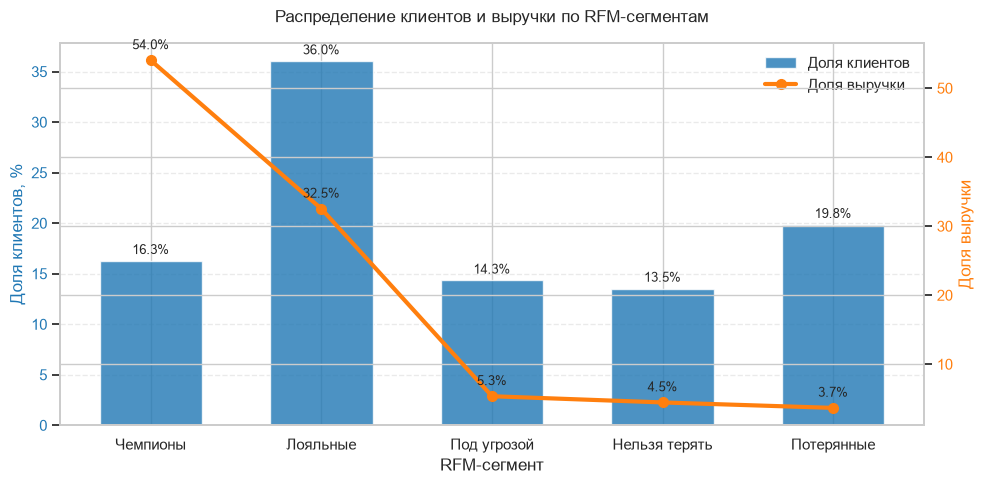

In [7]:
plot_rfm_share(
    df=rfm_df_sorted,
    segment_col="segment",
    customer_share_col="customer_share_pct",
    revenue_share_col="revenue_share_pct",
    xlabel="RFM-сегмент",
    ylabel="Доля клиентов, %",
    ax1label="Доля клиентов",
    ax2label="Доля выручки",
    title="Распределение клиентов и выручки по RFM-сегментам"
)

##### Вывод
Основную ценность формируют сегменты `Чемпионы` и `Лояльные` вместе они составляют **52,3%** клиентской базы и генерируют **86,5%** всей выручки.

### ABC-анализ клиентов

Для оценки концентрации выручки клиенты были разделены на три класса по накопительной доле выручки

- **A** — первые 80% выручки
- **B** — следующие 15%
- **C** — оставшиеся 5%

Посмотрим, как распределяются клиенты и выручка между этими классами.

In [8]:
abc_summary = read_sql_from_file("abc_summary")
abc_summary

,abc_revenue,customers,customer_share_pct,revenue,revenue_share_pct
0,A,2090,35.27,15355438.0,79.99
1,B,1968,33.21,2881560.0,15.01
2,C,1868,31.52,959842.0,5.00


Доля клиентов класса A составляет всего 35,3%, при этом они генерируют 79,99% всей выручки аптечной сети

In [9]:
abc_rfm_df = read_sql_from_file("abc_revenue")
abc_rfm_df.head()

,card,recency_days,purchase_cnt,total_revenue,r_score,f_score,m_score,rfm_code,segment,cum_revenue_pct,abc_revenue
0,2000200170860,1.0,129,163943,4,4,4,444,Чемпионы,0.85,A
1,2000200196556,0.0,103,122941,4,4,4,444,Чемпионы,1.49,A
2,2000200196600,9.0,65,120782,4,4,4,444,Чемпионы,2.12,A
3,2000200189985,0.0,217,112173,4,4,4,444,Чемпионы,2.71,A
4,2000200204541,2.0,68,102314,4,4,4,444,Чемпионы,3.24,A


In [10]:
pareto = abc_rfm_df.copy()

pareto = pareto.sort_values(
    by="total_revenue",
    ascending=False
).reset_index(drop=True)


pareto["customer_pct"] = (pareto.index + 1) / len(pareto) * 100
pareto["cum_revenue_pct"] = pareto["total_revenue"].cumsum() / pareto["total_revenue"].sum() * 100


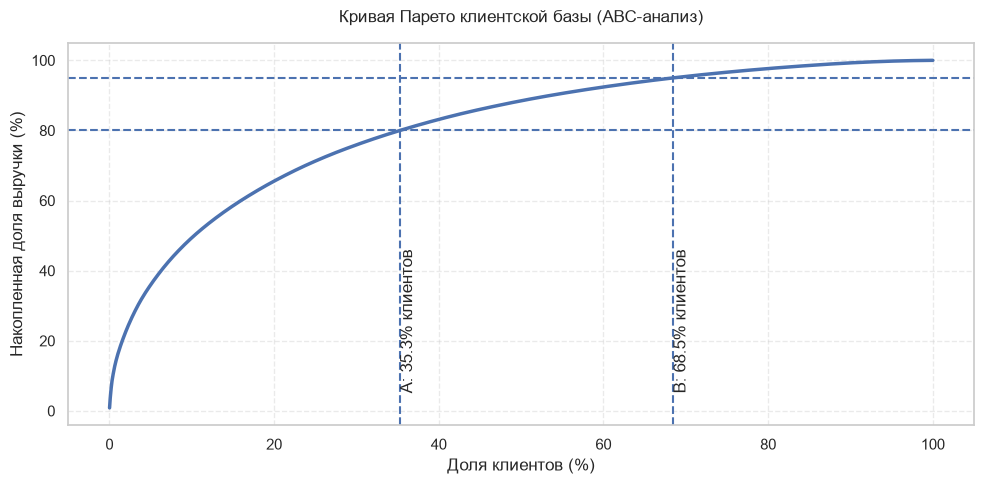

In [11]:
plot_pareto(
    df=pareto,
    customer_pct_col="customer_pct",
    revenue_pct_col="cum_revenue_pct"
)

#### Вывод

График подтверждает классический принцип Парето, что **35,3% клиентов генерируют 80% всей выручки** компании. Это означает сильную концентрацию доходов в руках относительно небольшой группы клиентов

### Распределение клиентов по RFM-сегментам и ABC-классам

Посмотрим, как RFM-сегменты распределяются внутри ABC-классов. Это позволяет увидеть, где теряются дорогие клиенты.

In [12]:
rfm_abc = (
    abc_rfm_df.groupby(['segment', 'abc_revenue'])
    .agg(customers=('card', 'count'))
    .reset_index()
)

pivot = rfm_abc.pivot(index='segment', columns='abc_revenue', values='customers').fillna(0)

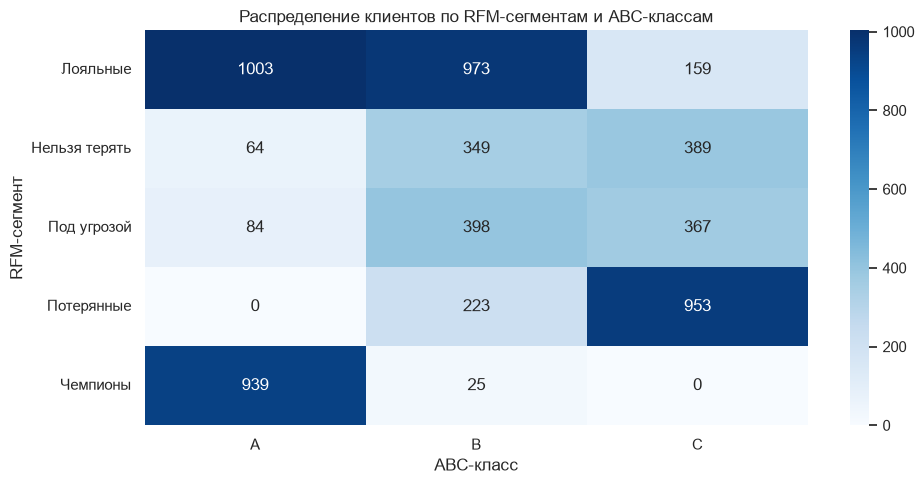

In [13]:
sns.heatmap(pivot,annot=True, fmt='.0f', cmap='Blues')
plt.title('Распределение клиентов по RFM-сегментам и ABC-классам')
plt.xlabel('ABC-класс') 
plt.ylabel('RFM-сегмент')
plt.tight_layout()
plt.show()

#### Вывод

1. Более 1900 клиентов (сегменты 'Лояльные' и 'Чемпионы' класса А) являются опорой бизнеса.
2. 84 клиента в категории Под угрозой' класса А. Потеря хотя бы 30% из них скажется на выручке. 
3. 25 клиентов из 'Чемпионов' в классе В идеальная группа для апселлинга, так как они уже активны, но не добирают по сумме.
4. Категория 'Потерянные' класса С насчитывает 953 клиента, а также значительное количество в классе В.

## Рекомендации по сегментам

| Сегмент | ABC-класс | Приоритет | Рекомендация |
| --- | --- | --- | --- |
| Чемпионы | A | Удержание | Персональные условия, VIP-предложения, бонусы за повторные покупки и ранний доступ к новинкам. |
| Лояльные | A/B | Развитие | Кросс-продажи, рекомендации по смежным товарам и программы для роста среднего чека. |
| Под угрозой | A/B | Реактивация | Целевые бонусы, напоминания о повторной покупке и персонализированные предложения для возврата в активное состояние. |
| Нельзя терять | A | Приоритетная win-back | Индивидуальные коммуникации, специальные условия и быстрый контакт с клиентом для предотвращения потери выручки. |
| Потерянные | B/C | Тестирование | Низкобюджетные win-back кампании с осторожным подходом и оценкой эффективности. |

**Ключевая мысль:** не все сегменты требуют одинакового уровня внимания. Наиболее ценные клиенты должны получать более сильные и персонализированные коммуникации, а менее активные — более осторожные и экономичные действия.

### Выгрузка сегментированных списков для маркетинга

In [14]:
export_folder = "data/exports/"
os.makedirs(export_folder, exist_ok=True)

export_rules = {
    'Чемпионы': ['A'],
    'Лояльные': ['A', 'B'],
    'Под угрозой': ['A', 'B'],
    'Нельзя терять': ['A'],
    'Потерянные': ['B', 'C']
}

In [15]:
for segment, abc_classes in export_rules.items():
    segment_data = abc_rfm_df[
        (abc_rfm_df['segment'] == segment) & 
        (abc_rfm_df['abc_revenue'].isin(abc_classes))
    ].copy()
    
    export_df = segment_data[['card', 'segment', 'abc_revenue']]
    
    file_path = f"{export_folder}{segment}.csv"
    export_df.to_csv(file_path, index=False)
    
    print(f"Файл '{segment}.csv' — выгружено клиентов: {len(export_df)} (ABC-классы: {', '.join(abc_classes)})")

Файл 'Чемпионы.csv' — выгружено клиентов: 939 (ABC-классы: A)
Файл 'Лояльные.csv' — выгружено клиентов: 1976 (ABC-классы: A, B)
Файл 'Под угрозой.csv' — выгружено клиентов: 482 (ABC-классы: A, B)
Файл 'Нельзя терять.csv' — выгружено клиентов: 64 (ABC-классы: A)
Файл 'Потерянные.csv' — выгружено клиентов: 1176 (ABC-классы: B, C)
